In [19]:
HYPERPARAM_ITERS = 1  # Number of iterations for hyperparameter tuning; TODO: increase this for better results, but it will take longer to run.
EXPORT = False  # Whether to export the trained models; set to True to save the models to disk.

# Data Preprocessing

While we did a lot of data cleaning and preprocessing in other notebooks (see notebooks in [data directory](./data)), we will load the data here and do some additional preprocessing to prepare it for model training. This includes combining flight and weather data, adding some historical and derived columns, as well as encoding categorical variables and splitting the data into training and testing sets.

In [20]:
import polars as pl

# Load the data
df = pl.read_parquet("data/flights/Full_Flight_Data.parquet")
df = df.sort("FL_DATE")
df.shape, df.head(), df.tail()

((480802, 60),
 shape: (5, 60)
 ┌─────────────┬─────────────┬────────────┬────────────┬───┬───────┬────────────┬────────────┬──────┐
 │ FL_DATE     ┆ MKT_UNIQUE_ ┆ MKT_CARRIE ┆ OP_UNIQUE_ ┆ … ┆ SPEED ┆ TC-DATA-SH ┆ TC-DATA-HO ┆      │
 │ ---         ┆ CARRIER     ┆ R_FL_NUM   ┆ CARRIER    ┆   ┆ ---   ┆ EET        ┆ LDER       ┆ ---  │
 │ datetime[μs ┆ ---         ┆ ---        ┆ ---        ┆   ┆ str   ┆ ---        ┆ ---        ┆ str  │
 │ ]           ┆ str         ┆ i64        ┆ str        ┆   ┆       ┆ str        ┆ str        ┆      │
 ╞═════════════╪═════════════╪════════════╪════════════╪═══╪═══════╪════════════╪════════════╪══════╡
 │ 2024-01-01  ┆ AA          ┆ 1064       ┆ AA         ┆ … ┆ 0000  ┆ A28NM      ┆ AIRBUS SAS ┆ null │
 │ 00:00:00    ┆             ┆            ┆            ┆   ┆       ┆            ┆ …          ┆      │
 │ 2024-01-01  ┆ AA          ┆ 1153       ┆ AA         ┆ … ┆ 0000  ┆            ┆ …          ┆ null │
 │ 00:00:00    ┆             ┆            ┆        

In [21]:
# Drop non-DCA originating flights
df = df.filter(pl.col("ORIGIN_AIRPORT_ID") == 11278)
df.shape, df.columns

((240391, 60),
 ['FL_DATE',
  'MKT_UNIQUE_CARRIER',
  'MKT_CARRIER_FL_NUM',
  'OP_UNIQUE_CARRIER',
  'OP_CARRIER_AIRLINE_ID',
  'TAIL_NUM',
  'OP_CARRIER_FL_NUM',
  'ORIGIN_AIRPORT_ID',
  'ORIGIN_CITY_MARKET_ID',
  'ORIGIN',
  'DEST_AIRPORT_ID',
  'CRS_DEP_TIME',
  'DEP_TIME',
  'DEP_DELAY',
  'DEP_DELAY_GROUP',
  'TAXI_OUT',
  'WHEELS_OFF',
  'WHEELS_ON',
  'TAXI_IN',
  'CRS_ARR_TIME',
  'ARR_TIME',
  'ARR_DELAY',
  'CANCELLED',
  'CANCELLATION_CODE',
  'DIVERTED',
  'CRS_ELAPSED_TIME',
  'ACTUAL_ELAPSED_TIME',
  'AIR_TIME',
  'FLIGHTS',
  'DISTANCE',
  'CARRIER_DELAY',
  'WEATHER_DELAY',
  'NAS_DELAY',
  'SECURITY_DELAY',
  'LATE_AIRCRAFT_DELAY',
  'FIRST_DEP_TIME',
  'DIV_AIRPORT_LANDINGS',
  'DIV_REACHED_DEST',
  'DIV_ACTUAL_ELAPSED_TIME',
  'N-NUMBER',
  'SERIAL NUMBER',
  'MFR MDL CODE',
  'ENG MFR MDL',
  'YEAR MFR',
  'N_NUMBER_CLEAN',
  'MFR_CODE_CLEAN',
  'CODE',
  'MFR',
  'MODEL',
  'TYPE-ACFT',
  'TYPE-ENG',
  'AC-CAT',
  'BUILD-CERT-IND',
  'NO-ENG',
  'NO-SEATS',
  'AC-W

In [22]:
# Bring in weather data
weather_df = pl.read_parquet("data/weather/isd_weather_data.parquet").sort("timestamp")

# Calculate the actual scheduled departure timestamp from the flight date and scheduled departure time. This keeps the weather alignment consistent with weather info that would have been available at the time of the scheduled departure
df = df.with_columns(
    (
        pl.col("FL_DATE")
        + pl.duration(
            hours=(pl.col("CRS_DEP_TIME") // 100).cast(pl.Int64),
            minutes=(pl.col("CRS_DEP_TIME") % 100).cast(pl.Int64),
        )
    ).alias("scheduled_departure_ts")
).sort("scheduled_departure_ts")

# Merge in most recent weather data that would have been known by scheduled departure
df = df.join_asof(
    weather_df,
    left_on="scheduled_departure_ts",
    right_on="timestamp",
    strategy="backward",
    tolerance="3h",
).drop("timestamp")
df.shape, df.head(), df.get_column("scheduled_departure_ts")

((240391, 73),
 shape: (5, 73)
 ┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
 │ FL_DATE   ┆ MKT_UNIQU ┆ MKT_CARRI ┆ OP_UNIQUE ┆ … ┆ precip-1h ┆ precip-6h ┆ visibilit ┆ ceiling_ │
 │ ---       ┆ E_CARRIER ┆ ER_FL_NUM ┆ _CARRIER  ┆   ┆ _trace    ┆ _trace    ┆ y_m       ┆ height_m │
 │ datetime[ ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
 │ μs]       ┆ str       ┆ i64       ┆ str       ┆   ┆ i32       ┆ i32       ┆ i32       ┆ i32      │
 ╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
 │ 2024-01-0 ┆ AA        ┆ 153       ┆ AA        ┆ … ┆ 0         ┆ 0         ┆ 16093     ┆ null     │
 │ 1         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
 │ 00:00:00  ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
 │ 2024-01-0 ┆ AA        ┆ 555       ┆ AA        ┆ 

In [23]:
df = df.sort("scheduled_departure_ts").with_row_index("_idx")

# Route average delay
df = df.with_columns(
    [
        pl.concat_str(
            pl.col("ORIGIN"), pl.lit("→"), pl.col("DEST_AIRPORT_ID").cast(pl.Utf8)
        ).alias("route"),
        pl.col("DEP_DELAY").cast(pl.Float64).alias("_dep_delay"),
        pl.col("CANCELLED").cast(pl.Float64).alias("_cancelled"),
    ]
)

df = df.with_columns(pl.col("_dep_delay").mean().over("route").alias("avg_rte_delay"))

# Airport congestion — cumulative sum trick (no join needed)
cumsum = df.select("scheduled_departure_ts").with_columns(
    pl.int_range(1, pl.len() + 1).alias("cum_count")
)

for col_name, hours in [
    ("deps_last_1h", 1),
    ("deps_last_3h", 3),
    ("deps_last_6h", 6),
    ("deps_last_12h", 12),
    ("deps_last_24h", 24),
]:
    lookback = (
        df.select(
            (pl.col("scheduled_departure_ts") - pl.duration(hours=hours)).alias(
                "ts_lookback"
            )
        )
        .join_asof(
            cumsum.rename(
                {
                    "scheduled_departure_ts": "ts_lookback",
                    "cum_count": "cum_at_lookback",
                }
            ),
            on="ts_lookback",
            strategy="backward",
        )
        .fill_null(0)
    )

    df = df.with_columns(
        (pl.int_range(1, pl.len() + 1) - pl.Series(lookback["cum_at_lookback"])).alias(
            col_name
        )
    )

# Carrier and airport rolling stats — compute once, join on _idx to avoid timestamp duplicates
df = df.with_columns(pl.int_range(pl.len()).alias("_idx"))

for window, suffix in [("1h", "hour"), ("1d", "day"), ("7d", "week"), ("30d", "month")]:
    # Airport-wide
    airport_agg = (
        df.rolling("scheduled_departure_ts", period=window, closed="left")
        .agg(
            [
                pl.col("_dep_delay").mean().alias(f"airport_avg_delay_{suffix}"),
                pl.col("_cancelled").mean().alias(f"airport_cancel_rate_{suffix}"),
            ]
        )
        .with_columns(pl.int_range(pl.len()).alias("_idx"))
    )
    df = df.join(
        airport_agg[
            ["_idx", f"airport_avg_delay_{suffix}", f"airport_cancel_rate_{suffix}"]
        ],
        on="_idx",
        how="left",
    )

    # Carrier-level (only week and month)
    if suffix in ("week", "month"):
        carrier_agg = (
            df.rolling(
                "scheduled_departure_ts",
                period=window,
                closed="left",
                group_by="MKT_UNIQUE_CARRIER",
            )
            .agg(
                [
                    pl.col("_dep_delay").mean().alias(f"carrier_avg_delay_{suffix}"),
                    pl.col("_cancelled").mean().alias(f"carrier_cancel_rate_{suffix}"),
                ]
            )
            .sort(["MKT_UNIQUE_CARRIER", "scheduled_departure_ts"])
            .with_columns(
                pl.int_range(pl.len()).over("MKT_UNIQUE_CARRIER").alias("_carrier_idx")
            )
        )
        df = df.with_columns(
            pl.int_range(pl.len()).over("MKT_UNIQUE_CARRIER").alias("_carrier_idx")
        )
        df = df.join(
            carrier_agg[
                [
                    "MKT_UNIQUE_CARRIER",
                    "_carrier_idx",
                    f"carrier_avg_delay_{suffix}",
                    f"carrier_cancel_rate_{suffix}",
                ]
            ],
            on=["MKT_UNIQUE_CARRIER", "_carrier_idx"],
            how="left",
        ).drop("_carrier_idx")

df = df.drop(["_idx", "_dep_delay", "_cancelled"])

In [24]:
import math as _math

# Time-of-day feature column names
TOD_HOUR = "tod_hour"
TOD_DOW = "tod_day_of_week"
TOD_MONTH = "tod_month"
TOD_WEEKEND = "tod_weekend"
TOD_BUCKET = "tod_departure_bucket"
TOD_HOUR_SIN = "tod_hour_sin"
TOD_HOUR_COS = "tod_hour_cos"

_TWO_PI_OVER_24 = 2 * _math.pi / 24

# All derived from scheduled_departure_ts (FL_DATE + CRS_DEP_TIME);
df = df.with_columns(
    [
        pl.col("scheduled_departure_ts").dt.hour().alias(TOD_HOUR),
        pl.col("scheduled_departure_ts").dt.weekday().alias(TOD_DOW),  # 0=Mon, 6=Sun
        pl.col("scheduled_departure_ts").dt.month().cast(pl.Int8).alias(TOD_MONTH),
        (pl.col("scheduled_departure_ts").dt.weekday() >= 5)
        .cast(pl.Int8)
        .alias(TOD_WEEKEND),
        pl.when(pl.col("scheduled_departure_ts").dt.hour() < 6)
        .then(pl.lit("late_night"))
        .when(pl.col("scheduled_departure_ts").dt.hour() < 12)
        .then(pl.lit("morning"))
        .when(pl.col("scheduled_departure_ts").dt.hour() < 18)
        .then(pl.lit("afternoon"))
        .when(pl.col("scheduled_departure_ts").dt.hour() < 22)
        .then(pl.lit("evening"))
        .otherwise(pl.lit("night"))
        .alias(TOD_BUCKET),
        (pl.col("scheduled_departure_ts").dt.hour() * _TWO_PI_OVER_24)
        .sin()
        .alias(TOD_HOUR_SIN),
        (pl.col("scheduled_departure_ts").dt.hour() * _TWO_PI_OVER_24)
        .cos()
        .alias(TOD_HOUR_COS),
    ]
)
df.select(
    [TOD_HOUR, TOD_DOW, TOD_MONTH, TOD_WEEKEND, TOD_BUCKET, TOD_HOUR_SIN, TOD_HOUR_COS]
).head()

tod_hour,tod_day_of_week,tod_month,tod_weekend,tod_departure_bucket,tod_hour_sin,tod_hour_cos
i8,i8,i8,i8,str,f64,f64
5,1,1,0,"""late_night""",0.965926,0.258819
5,1,1,0,"""late_night""",0.965926,0.258819
6,1,1,0,"""morning""",1.0,6.1232e-17
6,1,1,0,"""morning""",1.0,6.1232e-17
6,1,1,0,"""morning""",1.0,6.1232e-17


In [25]:
import math as _math

# --- Distance feature column names ---
DIST_LOG = "dist_log"
DIST_BUCKET = "dist_bucket"
DIST_WEATHER = "dist_x_weather_severity"

# weather_severity: composite 0–1 index averaged across three indicators (higher = worse)
_weather_severity = (
    (pl.col("windspeed").fill_null(0) / 150.0).clip(0.0, 1.0)
    + (1.0 - (pl.col("visibility_m").fill_null(16000) / 16000.0).clip(0.0, 1.0))
    + (pl.col("precipitation-1h").fill_null(0) > 0).cast(pl.Float64)
) / 3.0

df = df.with_columns(
    [
        pl.col("DISTANCE").log(_math.e).alias(DIST_LOG),
        pl.when(pl.col("DISTANCE") < 500)
        .then(pl.lit("short"))
        .when(pl.col("DISTANCE") < 1000)
        .then(pl.lit("medium"))
        .when(pl.col("DISTANCE") < 2000)
        .then(pl.lit("long"))
        .otherwise(pl.lit("very_long"))
        .alias(DIST_BUCKET),
        (pl.col("DISTANCE") * _weather_severity).alias(DIST_WEATHER),
    ]
)
df.select([DIST_LOG, DIST_BUCKET, DIST_WEATHER]).head()

dist_log,dist_bucket,dist_x_weather_severity
f64,str,f64
5.802118,"""short""",0.0
6.823286,"""medium""",0.0
6.70196,"""medium""",2.713333
6.304449,"""medium""",1.823333
6.416732,"""medium""",2.04


In [26]:
df = df.with_columns(
    pl.col(
        "MODEL"
    ).str.strip_chars()  # Remove leading/trailing whitespace from MODEL column (e.g., "737-800 " -> "737-800"
)
df.head()

FL_DATE,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,DEST_AIRPORT_ID,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_GROUP,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,FLIGHTS,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,DIV_AIRPORT_LANDINGS,…,windspeed,skycoverage,precipitation-1h,precipitation-6h,precip-1h_trace,precip-6h_trace,visibility_m,ceiling_height_m,route,avg_rte_delay,deps_last_1h,deps_last_3h,deps_last_6h,deps_last_12h,deps_last_24h,airport_avg_delay_hour,airport_cancel_rate_hour,airport_avg_delay_day,airport_cancel_rate_day,airport_avg_delay_week,airport_cancel_rate_week,carrier_avg_delay_week,carrier_cancel_rate_week,airport_avg_delay_month,airport_cancel_rate_month,carrier_avg_delay_month,carrier_cancel_rate_month,tod_hour,tod_day_of_week,tod_month,tod_weekend,tod_departure_bucket,tod_hour_sin,tod_hour_cos,dist_log,dist_bucket,dist_x_weather_severity
datetime[μs],str,i64,str,i64,str,i64,i64,i64,str,i64,i64,i64,f64,i64,f64,i64,i64,f64,i64,i64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,…,f64,str,f64,f64,i32,i32,i32,i32,str,f64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i8,i8,i8,i8,str,f64,f64,f64,str,f64
2024-01-01 00:00:00,"""AA""",153,"""AA""",19805,"""N894NN""",153,11278,30852,"""DCA""",11057,500,456,-4.0,-1,10.0,506,605,6.0,638,611,-27.0,0.0,null,0.0,98.0,75.0,59.0,1.0,331.0,null,null,null,null,null,null,0,…,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,"""DCA→11057""",18.570115,1,1,1,1,1,null,null,null,null,null,null,null,null,null,null,null,null,5,1,1,0,"""late_night""",0.965926,0.258819,5.802118,"""short""",0.0
2024-01-01 00:00:00,"""AA""",555,"""AA""",19805,"""N315RJ""",555,11278,30852,"""DCA""",13303,500,457,-3.0,-1,13.0,510,724,6.0,749,730,-19.0,0.0,null,0.0,169.0,153.0,134.0,1.0,919.0,null,null,null,null,null,null,0,…,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,"""DCA→13303""",17.055668,2,2,2,2,2,null,null,null,null,null,null,null,null,null,null,null,null,5,1,1,0,"""late_night""",0.965926,0.258819,6.823286,"""medium""",0.0
2024-01-01 00:00:00,"""AA""",2522,"""AA""",19805,"""N651AW""",2522,11278,30852,"""DCA""",15304,600,549,-11.0,-1,12.0,601,759,3.0,831,802,-29.0,0.0,null,0.0,151.0,133.0,118.0,1.0,814.0,null,null,null,null,null,null,0,…,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,"""DCA→15304""",16.452359,1,3,3,3,3,-3.5,0.0,-3.5,0.0,-3.5,0.0,-3.5,0.0,-3.5,0.0,-3.5,0.0,6,1,1,0,"""morning""",1.0,6.1232e-17,6.70196,"""medium""",2.713333
2024-01-01 00:00:00,"""DL""",410,"""DL""",19790,"""N375NC""",410,11278,30852,"""DCA""",10397,600,557,-3.0,-1,10.0,607,735,4.0,804,739,-25.0,0.0,null,0.0,124.0,102.0,88.0,1.0,547.0,null,null,null,null,null,null,0,…,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,"""DCA→10397""",15.774298,2,4,4,4,4,-3.5,0.0,-3.5,0.0,-3.5,0.0,null,null,-3.5,0.0,null,null,6,1,1,0,"""morning""",1.0,6.1232e-17,6.304449,"""medium""",1.823333
2024-01-01 00:00:00,"""UA""",260,"""UA""",19977,"""N37255""",260,11278,30852,"""DCA""",13930,600,552,-8.0,-1,10.0,602,634,8.0,717,642,-35.0,0.0,null,0.0,137.0,110.0,92.0,1.0,612.0,null,null,null,null,null,null,0,…,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,"""DCA→13930""",12.978764,3,5,5,5,5,-3.5,0.0,-3.5,0.0,-3.5,0.0,null,null,-3.5,0.0,null,null,6,1,1,0,"""morning""",1.0,6.1232e-17,6.416732,"""medium""",2.04


In [27]:
df = df.with_columns(
    pl.col(pl.Utf8).cast(pl.Categorical),
    pl.col("scheduled_departure_ts").dt.epoch(
        time_unit="s"
    ),  # Convert datetime to epoch seconds
)
df.head()

FL_DATE,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,DEST_AIRPORT_ID,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_GROUP,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,FLIGHTS,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,DIV_AIRPORT_LANDINGS,…,windspeed,skycoverage,precipitation-1h,precipitation-6h,precip-1h_trace,precip-6h_trace,visibility_m,ceiling_height_m,route,avg_rte_delay,deps_last_1h,deps_last_3h,deps_last_6h,deps_last_12h,deps_last_24h,airport_avg_delay_hour,airport_cancel_rate_hour,airport_avg_delay_day,airport_cancel_rate_day,airport_avg_delay_week,airport_cancel_rate_week,carrier_avg_delay_week,carrier_cancel_rate_week,airport_avg_delay_month,airport_cancel_rate_month,carrier_avg_delay_month,carrier_cancel_rate_month,tod_hour,tod_day_of_week,tod_month,tod_weekend,tod_departure_bucket,tod_hour_sin,tod_hour_cos,dist_log,dist_bucket,dist_x_weather_severity
datetime[μs],cat,i64,cat,i64,cat,i64,i64,i64,cat,i64,i64,i64,f64,i64,f64,i64,i64,f64,i64,i64,f64,f64,cat,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,cat,i64,…,f64,cat,f64,f64,i32,i32,i32,i32,cat,f64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i8,i8,i8,i8,cat,f64,f64,f64,cat,f64
2024-01-01 00:00:00,"""AA""",153,"""AA""",19805,"""N894NN""",153,11278,30852,"""DCA""",11057,500,456,-4.0,-1,10.0,506,605,6.0,638,611,-27.0,0.0,null,0.0,98.0,75.0,59.0,1.0,331.0,null,null,null,null,null,null,0,…,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,"""DCA→11057""",18.570115,1,1,1,1,1,null,null,null,null,null,null,null,null,null,null,null,null,5,1,1,0,"""late_night""",0.965926,0.258819,5.802118,"""short""",0.0
2024-01-01 00:00:00,"""AA""",555,"""AA""",19805,"""N315RJ""",555,11278,30852,"""DCA""",13303,500,457,-3.0,-1,13.0,510,724,6.0,749,730,-19.0,0.0,null,0.0,169.0,153.0,134.0,1.0,919.0,null,null,null,null,null,null,0,…,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,"""DCA→13303""",17.055668,2,2,2,2,2,null,null,null,null,null,null,null,null,null,null,null,null,5,1,1,0,"""late_night""",0.965926,0.258819,6.823286,"""medium""",0.0
2024-01-01 00:00:00,"""AA""",2522,"""AA""",19805,"""N651AW""",2522,11278,30852,"""DCA""",15304,600,549,-11.0,-1,12.0,601,759,3.0,831,802,-29.0,0.0,null,0.0,151.0,133.0,118.0,1.0,814.0,null,null,null,null,null,null,0,…,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,"""DCA→15304""",16.452359,1,3,3,3,3,-3.5,0.0,-3.5,0.0,-3.5,0.0,-3.5,0.0,-3.5,0.0,-3.5,0.0,6,1,1,0,"""morning""",1.0,6.1232e-17,6.70196,"""medium""",2.713333
2024-01-01 00:00:00,"""DL""",410,"""DL""",19790,"""N375NC""",410,11278,30852,"""DCA""",10397,600,557,-3.0,-1,10.0,607,735,4.0,804,739,-25.0,0.0,null,0.0,124.0,102.0,88.0,1.0,547.0,null,null,null,null,null,null,0,…,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,"""DCA→10397""",15.774298,2,4,4,4,4,-3.5,0.0,-3.5,0.0,-3.5,0.0,null,null,-3.5,0.0,null,null,6,1,1,0,"""morning""",1.0,6.1232e-17,6.304449,"""medium""",1.823333
2024-01-01 00:00:00,"""UA""",260,"""UA""",19977,"""N37255""",260,11278,30852,"""DCA""",13930,600,552,-8.0,-1,10.0,602,634,8.0,717,642,-35.0,0.0,null,0.0,137.0,110.0,92.0,1.0,612.0,null,null,null,null,null,null,0,…,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,"""DCA→13930""",12.978764,3,5,5,5,5,-3.5,0.0,-3.5,0.0,-3.5,0.0,null,null,-3.5,0.0,null,null,6,1,1,0,"""morning""",1.0,6.1232e-17,6.416732,"""medium""",2.04


In [28]:
#add buckets 
#bucket 0 is no delay (-inf to 15 min), 1 is 15-30 min, 2 is 30min-1hour, 3 is 1hour-1.5hours, 4 is 1.5-2, 5 is 2-2.5, 6 is 2.5-3, 7 is 3+
df = df.with_columns(
    pl.when(pl.col("DEP_DELAY") <= 15).then(0)
    .when(pl.col("DEP_DELAY") <= 30).then(1)
    .when(pl.col("DEP_DELAY") <= 60).then(2)
    .when(pl.col("DEP_DELAY") <= 90).then(3)
    .when(pl.col("DEP_DELAY") <= 120).then(4)
    .when(pl.col("DEP_DELAY") <= 150).then(5)
    .when(pl.col("DEP_DELAY") <= 180).then(6)
    .otherwise(7)
    .alias("delay_bucket")
)


In [29]:
# Copy dataset with cancelled flights dropped, to be used for regression model training (delay prediction)
non_cancelled_df = df.select(pl.all()).filter(pl.col("CANCELLED") == 0)
non_cancelled_df.shape, non_cancelled_df.head()

((233124, 103),
 shape: (5, 103)
 ┌───────────┬───────────┬───────────┬───────────┬───┬──────────┬───────────┬───────────┬───────────┐
 │ FL_DATE   ┆ MKT_UNIQU ┆ MKT_CARRI ┆ OP_UNIQUE ┆ … ┆ dist_log ┆ dist_buck ┆ dist_x_we ┆ delay_buc │
 │ ---       ┆ E_CARRIER ┆ ER_FL_NUM ┆ _CARRIER  ┆   ┆ ---      ┆ et        ┆ ather_sev ┆ ket       │
 │ datetime[ ┆ ---       ┆ ---       ┆ ---       ┆   ┆ f64      ┆ ---       ┆ erity     ┆ ---       │
 │ μs]       ┆ cat       ┆ i64       ┆ cat       ┆   ┆          ┆ cat       ┆ ---       ┆ i32       │
 │           ┆           ┆           ┆           ┆   ┆          ┆           ┆ f64       ┆           │
 ╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪══════════╪═══════════╪═══════════╪═══════════╡
 │ 2024-01-0 ┆ AA        ┆ 153       ┆ AA        ┆ … ┆ 5.802118 ┆ short     ┆ 0.0       ┆ 0         │
 │ 1         ┆           ┆           ┆           ┆   ┆          ┆           ┆           ┆           │
 │ 00:00:00  ┆           ┆           ┆           

## Prepare the data for model training

In [30]:
# Extract features and target variable for both classification and regression models
cols = [
    # Flight info
    "scheduled_departure_ts",
    "MKT_UNIQUE_CARRIER",
    "MKT_CARRIER_FL_NUM",
    "DEST_AIRPORT_ID",
    "CRS_DEP_TIME",
    "DISTANCE",
    "MODEL",
    "avg_rte_delay",
    "deps_last_1h",
    "deps_last_3h",
    "deps_last_6h",
    "deps_last_12h",
    "deps_last_24h",
    "carrier_avg_delay_week",
    "carrier_avg_delay_month",
    "carrier_cancel_rate_month",
    "carrier_cancel_rate_week",
    "airport_avg_delay_hour",
    "airport_cancel_rate_hour",
    "airport_avg_delay_day",
    "airport_cancel_rate_day",
    "airport_avg_delay_week",
    "airport_cancel_rate_week",
    "airport_avg_delay_month",
    "airport_cancel_rate_month",
    # Distance features
    "dist_log",
    "dist_bucket",
    "dist_x_weather_severity",
    # Time of day features
    "tod_hour",
    "tod_day_of_week",
    "tod_month",
    "tod_weekend",
    "tod_departure_bucket",
    "tod_hour_sin",
    "tod_hour_cos",
    # Weather info
    "temp",
    "dewtemp",
    "pressure",
    "winddirection",
    "windspeed",
    "skycoverage",
    "precipitation-1h",
    "precipitation-6h",
    "precip-1h_trace",
    "precip-6h_trace",
    "visibility_m",
    "ceiling_height_m",
]
x = non_cancelled_df.select(cols)
y = non_cancelled_df.get_column("delay_bucket")

x_cancel = df.select(cols)
y_cancel = df.select("CANCELLED")
x.shape, y.shape, x_cancel.shape, y_cancel.shape

((233124, 47), (233124,), (240391, 47), (240391, 1))

In [31]:
# Cancelled dataset
x_cancel = x_cancel.select(pl.all().exclude("CANCELLED"))
x_cancel.head(), x_cancel.shape, y_cancel.shape

(shape: (5, 47)
 ┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
 │ scheduled ┆ MKT_UNIQU ┆ MKT_CARRI ┆ DEST_AIRP ┆ … ┆ precip-1h ┆ precip-6h ┆ visibilit ┆ ceiling_ │
 │ _departur ┆ E_CARRIER ┆ ER_FL_NUM ┆ ORT_ID    ┆   ┆ _trace    ┆ _trace    ┆ y_m       ┆ height_m │
 │ e_ts      ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
 │ ---       ┆ cat       ┆ i64       ┆ i64       ┆   ┆ i32       ┆ i32       ┆ i32       ┆ i32      │
 │ i64       ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
 ╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
 │ 170408520 ┆ AA        ┆ 153       ┆ 11057     ┆ … ┆ 0         ┆ 0         ┆ 16093     ┆ null     │
 │ 0         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
 │ 170408520 ┆ AA        ┆ 555       ┆ 13303     ┆ … ┆ 0         ┆

## Encode categorical features

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

categorical_cols = [col for col in x.columns if x[col].dtype == pl.Categorical]

# create column transformer -- https://stackoverflow.com/a/77965041
transformer = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(), categorical_cols),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)
transformer.set_output(transform="polars")

# Fit and transform the data
transformer.fit(df.select(cols))
x = transformer.transform(x)
x_cancel = transformer.transform(x_cancel)
x.head(), x_cancel.head()

(shape: (5, 47)
 ┌────────────┬───────┬────────────┬────────────┬───┬───────────┬───────────┬───────────┬───────────┐
 │ MKT_UNIQUE ┆ MODEL ┆ dist_bucke ┆ tod_depart ┆ … ┆ precip-1h ┆ precip-6h ┆ visibilit ┆ ceiling_h │
 │ _CARRIER   ┆ ---   ┆ t          ┆ ure_bucket ┆   ┆ _trace    ┆ _trace    ┆ y_m       ┆ eight_m   │
 │ ---        ┆ f64   ┆ ---        ┆ ---        ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
 │ f64        ┆       ┆ f64        ┆ f64        ┆   ┆ i32       ┆ i32       ┆ i32       ┆ i32       │
 ╞════════════╪═══════╪════════════╪════════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
 │ 0.0        ┆ 22.0  ┆ 2.0        ┆ 2.0        ┆ … ┆ 0         ┆ 0         ┆ 16093     ┆ null      │
 │ 0.0        ┆ 20.0  ┆ 1.0        ┆ 2.0        ┆ … ┆ 0         ┆ 0         ┆ 16093     ┆ null      │
 │ 0.0        ┆ 49.0  ┆ 1.0        ┆ 3.0        ┆ … ┆ 0         ┆ 0         ┆ 16000     ┆ null      │
 │ 3.0        ┆ 47.0  ┆ 1.0        ┆ 3.0        ┆ … ┆ 0         ┆ 

In [33]:
# Get the feature names after transformation, and the category-to-integer mappings for the categorical features
category_mappings = {
    col: {
        j: label
        for j, label in enumerate(transformer.named_transformers_["cat"].categories_[i])
    }
    for i, col in enumerate(categorical_cols)
}
category_mappings

{'MKT_UNIQUE_CARRIER': {0: 'AA',
  1: 'AS',
  2: 'B6',
  3: 'DL',
  4: 'F9',
  5: 'UA',
  6: 'WN'},
 'MODEL': {0: '717-200',
  1: '737-700',
  2: '737-71B',
  3: '737-71Q',
  4: '737-724',
  5: '737-73V',
  6: '737-752',
  7: '737-76N',
  8: '737-76Q',
  9: '737-79L',
  10: '737-79P',
  11: '737-7BD',
  12: '737-7BK',
  13: '737-7CT',
  14: '737-7H4',
  15: '737-7K5',
  16: '737-7K9',
  17: '737-7L9',
  18: '737-7Q8',
  19: '737-7V3',
  20: '737-8',
  21: '737-800',
  22: '737-823',
  23: '737-824',
  24: '737-832',
  25: '737-890',
  26: '737-8EH',
  27: '737-8FH',
  28: '737-8H4',
  29: '737-9',
  30: '737-900ER',
  31: '737-924ER',
  32: '737-932ER',
  33: '737-990ER',
  34: '757-224',
  35: '757-231',
  36: '757-232',
  37: '757-251',
  38: '757-2Q8',
  39: '757-324',
  40: '757-33N',
  41: 'A319-112',
  42: 'A319-114',
  43: 'A319-115',
  44: 'A319-131',
  45: 'A319-132',
  46: 'A320-211',
  47: 'A320-212',
  48: 'A320-214',
  49: 'A320-232',
  50: 'A320-251N',
  51: 'A321-211',
 

## Train, validation, test split
We'll split the data first into validation and test sets. When we do hyperparameter tuning, we'll use the validation set with cross-validation to evaluate different hyperparameter combinations, and then we'll do a final evaluation on the test set to get the estimate of our model's performance on unseen data.

In [34]:
from sklearn.model_selection import train_test_split

# Split the cancelled dataset
x_cancel_val, x_cancel_test, y_cancel_val, y_cancel_test = train_test_split(
    x_cancel, y_cancel, test_size=0.2, shuffle=False
)
x_cancel_val.shape, x_cancel_test.shape, y_cancel_val.shape, y_cancel_test.shape

((192312, 47), (48079, 47), (192312, 1), (48079, 1))

In [35]:
# Split the non-cancelled dataset
X_val, X_test, y_val, y_test = train_test_split(x, y, test_size=0.2, shuffle=False)
X_val.shape, X_test.shape, y_val.shape, y_test.shape

((186499, 47), (46625, 47), (186499,), (46625,))

# Train the model
## Train a Random Forest Classifier for cancellation prediction

In [36]:
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# Random forest for cancellation prediction
rf_cancel = RandomForestClassifier(random_state=0)

# Hyperparameter tuning
clf_param_dist = {
    "n_estimators": randint(200, 1001),
    "max_depth": [None, 10, 20, 30, 40, 50, 60],
    "min_samples_split": randint(2, 21),
    "min_samples_leaf": randint(1, 9),
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, 1.0],
    "bootstrap": [True, False],
    "class_weight": [None, "balanced"],
}
rfc_random = RandomizedSearchCV(
    rf_cancel,
    param_distributions=clf_param_dist,
    n_iter=HYPERPARAM_ITERS,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2,
    random_state=0,
)
search = rfc_random.fit(x_cancel_val.to_numpy(), y_cancel_val.to_numpy().ravel())
print("Best Hyperparameters:", search.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/Library/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Library/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Library/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Library/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Library/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or

[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=559; total time=  19.5s
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=559; total time=  47.2s
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=559; total time= 1.3min
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=559; total time= 1.8min
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=559; total time= 2.5min
Best Hyperparameters: {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 559}


In [37]:
rfc_random.score(x_cancel_test.to_numpy(), y_cancel_test.to_numpy().ravel())

0.9075594109041599

In [38]:
# Table of predicted probabilities and actual labels
y_cancel_pred = rfc_random.predict_proba(x_cancel_test.to_numpy())[:, 1]
cancel_df = pl.DataFrame(
    {
        "predicted_cancel_prob": y_cancel_pred,
        "actual_cancelled": y_cancel_test.to_numpy().ravel(),
    }
)
# treat actual as boolean
cancel_df = cancel_df.with_columns(pl.col("actual_cancelled").cast(pl.Boolean))
cancel_df.sample(20)

predicted_cancel_prob,actual_cancelled
f64,bool
0.057995,false
0.036257,false
0.118072,false
0.077256,false
0.045428,false
…,…
0.064518,false
0.06719,false
0.071216,false


## Train a Random Forest Classifier for delay prediction

In [39]:
from sklearn.ensemble import RandomForestClassifier

# Classify delay bucket (0-7)
delay_clf = RandomForestClassifier(random_state=0, oob_score=True)

# Hyperparameter tuning
delay_clf_param_dist = {
    "n_estimators": randint(200, 1001),
    "max_depth": [None, 10, 20, 30, 40, 50, 60],
    "min_samples_split": randint(2, 21),
    "min_samples_leaf": randint(1, 9),
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, 1.0],
    "bootstrap": [True, False],
    "class_weight": [None, "balanced"],
}
delay_clf_random = RandomizedSearchCV(
    delay_clf,
    param_distributions=delay_clf_param_dist,
    n_iter=HYPERPARAM_ITERS,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="f1_weighted",  # weighted F1 handles class imbalance across 8 buckets
    n_jobs=-1,
    verbose=2,
    random_state=0,
)
delay_search = delay_clf_random.fit(X_val, y_val)
print("Best Hyperparameters:", delay_search.best_params_)


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/Library/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Library/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Library/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Library/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=559; total time=  34.2s
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=559; total time= 1.3min
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=559; total time= 1.9min
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=559; total time= 2.6min
[CV] END bootstrap=True, class_weight=balanced, max_depth=50, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=559; total time= 3.5min
Best Hyperparameters: {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 559}


# Evaluation

In [40]:
importances = delay_search.best_estimator_.feature_importances_
feature_names = X_val.columns

importance_df = pl.DataFrame(
    {
        "feature": feature_names,
        "importance": importances,
    }
).sort("importance", descending=True)

importance_df.show(None)


feature,importance
str,f64
"""airport_avg_delay_hour""",0.044802
"""airport_avg_delay_day""",0.038984
"""MKT_CARRIER_FL_NUM""",0.037368
"""carrier_avg_delay_week""",0.035984
"""dist_x_weather_severity""",0.035275
"""carrier_avg_delay_month""",0.03423
"""airport_avg_delay_week""",0.032889
"""deps_last_12h""",0.032069
"""airport_avg_delay_month""",0.03184


Out-of-Bag Score: 0.7785832631810359
Accuracy: 0.6946
Classification Report:
                   precision    recall  f1-score   support

0: on-time (≤15m)       0.78      0.93      0.85     33679
        1: 15-30m       0.16      0.02      0.04      3437
        2: 30-60m       0.16      0.13      0.14      3603
        3: 60-90m       0.11      0.04      0.06      1927
       4: 90-120m       0.10      0.02      0.04      1126
      5: 120-150m       0.10      0.03      0.05       773
      6: 150-180m       0.07      0.02      0.03       531
         7: 180m+       0.28      0.36      0.31      1549

         accuracy                           0.69     46625
        macro avg       0.22      0.19      0.19     46625
     weighted avg       0.61      0.69      0.64     46625



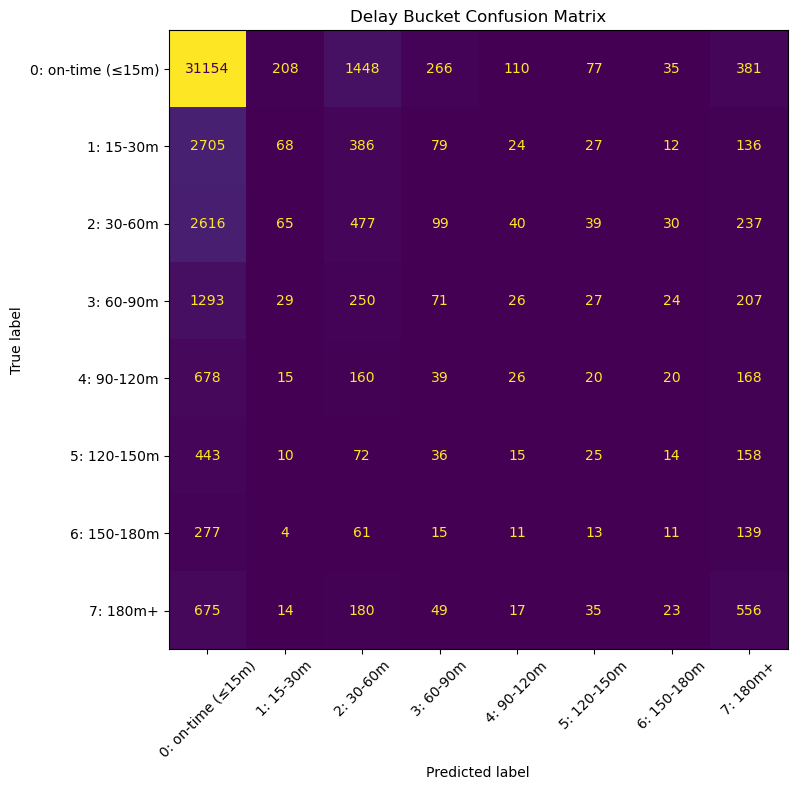

In [42]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

bucket_labels = [
    "0: on-time (≤15m)",
    "1: 15-30m",
    "2: 30-60m",
    "3: 60-90m",
    "4: 90-120m",
    "5: 120-150m",
    "6: 150-180m",
    "7: 180m+",
]

# Evaluate
print("Out-of-Bag Score:", delay_search.best_estimator_.oob_score_)

y_pred = delay_search.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=bucket_labels))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=bucket_labels)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Delay Bucket Confusion Matrix")
plt.tight_layout()
plt.show()


In [ ]:
import random

rand_start = random.randint(0, len(y_test) - 20)
print(f"{"Actual":>8} {"Predicted":>10} {"Match":>6}")
for actual, predicted in zip(
    y_test[rand_start : rand_start + 20], y_pred[rand_start : rand_start + 20]
):
    match = "✓" if actual == predicted else "✗"
    print(f"{actual:8d} {int(predicted):10d} {match:>6}")


# Save the trained models for later use

In [ ]:
# Save models with ONNX -- https://scikit-learn.org/stable/model_persistence.html#onnx
import json
from pathlib import Path

if EXPORT:
    # cancel_onnx = to_onnx(
    #     rfc_random.best_estimator_,
    #     X=x_cancel_val.to_numpy().astype("float32"),
    # )
    # regress_onnx = to_onnx(
    #     rfr_random.best_estimator_,
    #     X=X_val.to_numpy().astype("float32"),
    # )

    models_dir = Path("models")
    models_dir.mkdir(parents=True, exist_ok=True)

    # with open("models/cancel_model.onnx", "wb") as f:
    #     f.write(cancel_onnx.SerializeToString())
    # with open("models/regress_model.onnx", "wb") as f:
    #     f.write(regress_onnx.SerializeToString())

    metadata = {
        "feature_columns": cols,
        "classifier_features": x_cancel_val.columns,
        "delay_clf_features": X_val.columns,
        "categorical_columns": categorical_cols,
        "categorical_mappings": category_mappings,
        "classifier_best_params": rfc_random.best_params_,
        "delay_clf_best_params": delay_clf_random.best_params_,
    }
    with open(models_dir / "metadata.json", "w") as f:
        json.dump(metadata, f, indent=2, default=str)